In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import xarray as xr
import os, sys
os.environ['CUDA_VISIBLE_DEVICES'] = '3,4,5,6,7'

sys.path.insert(0, '../')
import visualization, sensor, grid, line_rte
from network import shard
from consts import *

data_dir = '../../data/RADMC3D_input_files'

Load a dataset
---

In [2]:
# Load volumetric fields 
r, theta, phi = grid.read_spherical_amr(os.path.join(data_dir, 'amr_grid.inp'))
dataset = xr.load_dataset(os.path.join(data_dir, 'dataset_spherical.nc'))
number_density = jnp.array(dataset.numberdens_12c16o)
temperature = jnp.array(dataset.dust_temperature)
velocity = jnp.array(dataset.gas_velocity)

# 3D domain parameters
phi_min, phi_max = phi[0], phi[-1]
theta_min, theta_max = theta[0], theta[-1]
r_min, r_max = r[0], r[-1]

# Bounding box for interpolations (logarithmic r scale)
bbox = [(phi_min, phi_max), (theta_min, theta_max), (np.log10(r_min), np.log10(r_max))]

Define a "camera" projection geometry
---

In [3]:
# Sensor parameters
npix = 384
nray = 100
incl = 45.0
phi  = 100.0
posang = 0.0

fov = np.float32(1.1) * 2*r[-1]  # Note: float32 is to match radmc3d exact pixel grid
pixel_area = (fov/npix)**2       # pixel area to convert radiances to Jy 

ray_coords, obs_dir = sensor.orthographic_disk_projection(npix, nray, incl, phi, posang, fov, r_min, r_max, theta_min, theta_max)
ray_coords_sph = grid.cartesian_to_spherical(ray_coords, logr=True)

Line radiative transfer
---

In [4]:
# Interpolate dataset along the (spherical) ray coordinates
gas_nd = grid.interpolate_scalar(number_density, ray_coords_sph, bbox)
gas_t  = grid.interpolate_scalar(temperature, ray_coords_sph, bbox, cval=1e-10)

# Einstein coefficient for spontaneous emission from level u to level d
energy_levels, radiative_transitions = line_rte.load_molecular_tables(path=os.path.join(data_dir, 'molecule_12c16o.inp'))
nu0, a_ud, b_ud, b_du = line_rte.einstein_coefficients(energy_levels, radiative_transitions)
n_up, n_dn = line_rte.n_up_down(gas_nd, gas_t, energy_levels, radiative_transitions)
print('line frequency: {} Ghz'.format(nu0/ghz))

line frequency: 345.7959899 Ghz


In [5]:
# Compute line radiative transfer for a whole spectral cube
width_kms = 3.65
linenlam = 50
alpha_turb = 0.0
camera_freqs = sensor.compute_camera_freqs(linenlam, width_kms, nu0)

gas_v = grid.interpolate_vector(velocity, ray_coords, ray_coords_sph, bbox)

# Define a parallel mapping over several gpus
pmap = jax.pmap(line_rte.compute_spectral_cube,
                axis_name='freq', 
                in_axes=(0, None, None, None, None, None, None, None, None, None, None, None, None))

print('computing spectral cube for a total of {} frequencies'.format(camera_freqs.size))
images = pmap(shard(camera_freqs), gas_v, gas_t, n_up, n_dn, a_ud, b_ud, b_du, ray_coords, obs_dir, nu0, pixel_area, alpha_turb)
images = np.nan_to_num(images).reshape(linenlam, npix, npix)

computing spectral cube for a total of 50 frequencies


interactive(children=(IntSlider(value=24, description='frame', max=49), Output()), _dom_classes=('widget-inter…

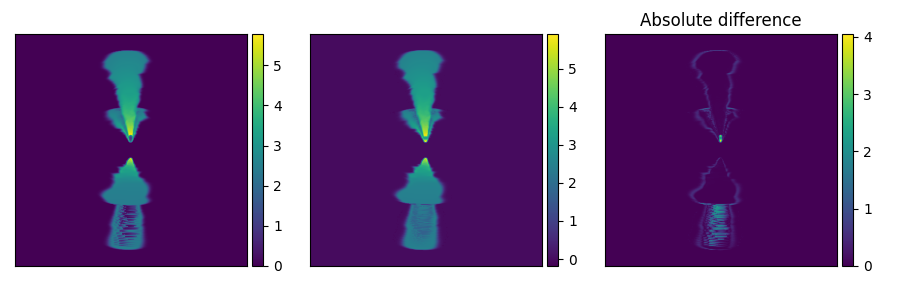

In [6]:
import disksurf
cube = disksurf.observation(os.path.join(data_dir, 'image_test.fits'))

%matplotlib widget
visualization.slider_frame_comparison(cube.data, images)

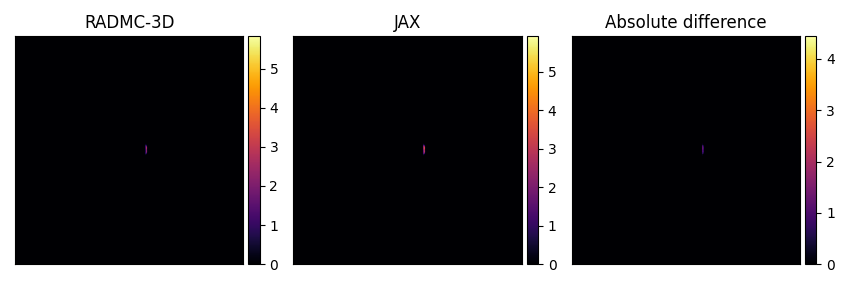

In [17]:
fig, axes = plt.subplots(1,3,sharey=True, figsize=(8.5,3))
movie_list = [cube.data, images, np.abs(cube.data-images)]
titles = ['RADMC-3D', 'JAX', 'Absolute difference']
output = 'gifs/radmc_jax_comparison_nfreq{}_nray{}.gif'.format(linenlam, nray)
visualization.animate_movies_synced(movie_list, axes, fov=fov, vmin=[0.0]*3, cmaps='inferno', titles=titles, output=output)